In [1]:
import numpy as np
w = np.array([2, 1, 5, 3])
x = np.array([2, 8, 3, 7, 1, 2, 0, 4, 5])
# w_r = w[::-1]
w_r = np.flip(w)
print(w_r)

[3 5 1 2]


In [2]:
for i in range(6):
    print(np.dot(x[i:i+4], w_r))

63
48
49
28
21
20


In [3]:
from scipy.signal import convolve
convolve(x, w, mode='valid')	# 합성곱

array([63, 48, 49, 28, 21, 20])

In [4]:
from scipy.signal import correlate
correlate(x, w, mode='valid')

array([48, 57, 24, 25, 16, 39])

In [5]:
correlate(x, w, mode='full')	# zero padding (연산 참여도 바꿈)

array([ 6, 34, 51, 48, 57, 24, 25, 16, 39, 29, 13, 10])

In [6]:
correlate(x, w, mode='same')	# same padding (출력 배열 길이 = 원본 배열 길이)

array([34, 51, 48, 57, 24, 25, 16, 39, 29])

In [7]:
from scipy.signal import correlate2d
x = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
w = np.array([[2, 0], [0, 0]])
correlate2d(x, w, mode='valid')

array([[ 2,  4],
       [ 8, 10]])

In [8]:
correlate2d(x, w, mode='same')

array([[ 2,  4,  6],
       [ 8, 10, 12],
       [14, 16, 18]])

In [9]:
import tensorflow as tf
x_4d = x.astype(float).reshape(1, 3, 3, 1)
w_4d = w.reshape(2, 2, 1, 1)

In [10]:
c_out = tf.nn.conv2d(x_4d, w_4d, strides=1, padding='SAME')
c_out.numpy().reshape(3, 3)

array([[ 2.,  4.,  6.],
       [ 8., 10., 12.],
       [14., 16., 18.]])

In [11]:
import torch
import torch.nn as nn

# KEY DIFFERENCE — tensor dimension ordering:
#   TensorFlow : NHWC → (batch, height, width, channels)  → reshape(1, 3, 3, 1)
#   PyTorch    : NCHW → (batch, channels, height, width)  → reshape(1, 1, 3, 3)
x_4d_pt = torch.tensor(x).float().reshape(1, 1, 3, 3)

# nn.Conv2d is the high-level layer API — equivalent to tf.keras.layers.Conv2D
# Unlike tf.nn.conv2d (low-level), it owns its weights internally as nn.Parameter
# in_channels=1, out_channels=1, kernel_size=2 matches the 2×2 kernel w used above
conv_layer = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=2, padding='same', bias=False)

# Manually assign w to match the TF example (normally the layer initialises weights randomly)
# KEY DIFFERENCE — weight shape ordering:
#   TensorFlow : (height, width, in_channels, out_channels) → reshape(2, 2, 1, 1)
#   PyTorch    : (out_channels, in_channels, height, width) → reshape(1, 1, 2, 2)
conv_layer.weight = nn.Parameter(torch.tensor(w).float().reshape(1, 1, 2, 2))

c_out_pt = conv_layer(x_4d_pt)

# .detach() drops gradient tracking before reshaping — TF tensors don't require this step
c_out_pt.detach().reshape(3, 3)

c:\Users\USER\Desktop\AI\Do_it\.venv\Lib\site-packages\torch\nn\modules\conv.py:560: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\native\Convolution.cpp:1091.)
  return F.conv2d(


tensor([[ 2.,  4.,  6.],
        [ 8., 10., 12.],
        [14., 16., 18.]])

In [12]:
# 풀링 연산
x = np.array([[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12], [13, 14, 15, 16]])
# B, H, W, C
x = x.reshape(1, 4, 4, 1)

In [13]:
p_out = tf.nn.max_pool2d(x, ksize=2, strides=2, padding='VALID')
print(p_out)
p_out.numpy().reshape(2, 2)

tf.Tensor(
[[[[ 6.]
   [ 8.]]

  [[14.]
   [16.]]]], shape=(1, 2, 2, 1), dtype=float32)


array([[ 6.,  8.],
       [14., 16.]], dtype=float32)

In [14]:
x_t = torch.tensor(x)
# B, C, H, W
x_t = x_t.reshape(1, 1, 4, 4)
p_out_t = torch.nn.functional.max_pool2d(x_t, kernel_size=2, stride=2)
p_out_t.numpy().reshape(2, 2)

array([[ 6,  8],
       [14, 16]])

In [15]:
def relu(x):
    return np.maximum(x, 0)

x = np.array([-1, 2, -3, 4, -5])
relu(x)

array([0, 2, 0, 4, 0])

In [16]:
# tensorflow
r_out = tf.nn.relu(x)
print(r_out.numpy())

# torch
x_t = torch.tensor(x)
torch_relu = torch.nn.ReLU()
r_out_t = torch_relu(x_t)
print(r_out_t.numpy())

[0 2 0 4 0]
[0 2 0 4 0]


In [17]:
# textbook Tensorflow version
import tensorflow as tf

class ConvolutionNetwork_tf:
    
    def __init__(self, n_kernels=10, units=10, batch_size=32, learning_rate=0.1):
        self.n_kernels = n_kernels  # 합성곱의 커널 개수
        self.kernel_size = 3        # 커널 크기
        self.optimizer = None       # 옵티마이저
        self.conv_w = None          # 합성곱 층의 가중치
        self.conv_b = None          # 합성곱 층의 절편
        self.units = units          # 은닉층의 뉴런 개수
        self.batch_size = batch_size  # 배치 크기
        self.w1 = None              # 은닉층의 가중치
        self.b1 = None              # 은닉층의 절편
        self.w2 = None              # 출력층의 가중치
        self.b2 = None              # 출력층의 절편
        self.a1 = None              # 은닉층의 활성화 출력
        self.losses = []            # 훈련 손실
        self.val_losses = []        # 검증 손실
        self.lr = learning_rate     # 학습률

    def forpass(self, x):
        # 3x3 합성곱 연산을 수행합니다.
        c_out = tf.nn.conv2d(x, self.conv_w, strides=1, padding='SAME') + self.conv_b
        # 렐루 활성화 함수를 적용합니다.
        r_out = tf.nn.relu(c_out)
        # 2x2 최대 풀링을 적용합니다.
        p_out = tf.nn.max_pool2d(r_out, ksize=2, strides=2, padding='VALID')
        # 첫 번째 배치 차원을 제외하고 출력을 일렬로 펼칩니다.
        f_out = tf.reshape(p_out, [x.shape[0], -1])
        z1 = tf.matmul(f_out, self.w1) + self.b1     # 첫 번째 층의 선형 식을 계산합니다
        a1 = tf.nn.relu(z1)                          # 활성화 함수를 적용합니다
        z2 = tf.matmul(a1, self.w2) + self.b2        # 두 번째 층의 선형 식을 계산합니다.
        return z2
    
    def init_weights(self, input_shape, n_classes):
        g = tf.initializers.glorot_uniform()
        self.conv_w = tf.Variable(g((3, 3, 1, self.n_kernels)))
        self.conv_b = tf.Variable(np.zeros(self.n_kernels), dtype=float)
        n_features = 14 * 14 * self.n_kernels
        self.w1 = tf.Variable(g((n_features, self.units)))          # (특성 개수, 은닉층의 크기)
        self.b1 = tf.Variable(np.zeros(self.units), dtype=float)    # 은닉층의 크기
        self.w2 = tf.Variable(g((self.units, n_classes)))           # (은닉층의 크기, 클래스 개수)
        self.b2 = tf.Variable(np.zeros(n_classes), dtype=float)     # 클래스 개수
        
    def fit(self, x, y, epochs=100, x_val=None, y_val=None):
        self.init_weights(x.shape, y.shape[1])    # 은닉층과 출력층의 가중치를 초기화합니다.
        self.optimizer = tf.optimizers.SGD(learning_rate=self.lr)
        # epochs만큼 반복합니다.
        for i in range(epochs):
            print('에포크', i, end=' ')
            # 제너레이터 함수에서 반환한 미니배치를 순환합니다.
            batch_losses = []
            for x_batch, y_batch in self.gen_batch(x, y):
                print('.', end='')
                self.training(x_batch, y_batch)
                # 배치 손실을 기록합니다.
                batch_losses.append(self.get_loss(x_batch, y_batch))
            print()
            # 배치 손실 평균내어 훈련 손실 값으로 저장합니다.
            self.losses.append(np.mean(batch_losses))
            # 검증 세트에 대한 손실을 계산합니다.
            self.val_losses.append(self.get_loss(x_val, y_val))

    # 미니배치 제너레이터 함수
    def gen_batch(self, x, y):
        bins = len(x) // self.batch_size                   # 미니배치 횟수
        indexes = np.random.permutation(np.arange(len(x))) # 인덱스를 섞습니다.
        x = x[indexes]
        y = y[indexes]
        for i in range(bins):
            start = self.batch_size * i
            end = self.batch_size * (i + 1)
            yield x[start:end], y[start:end]   # batch_size만큼 슬라이싱하여 반환합니다.
            
    def training(self, x, y):
        m = len(x)                    # 샘플 개수를 저장합니다.
        with tf.GradientTape() as tape:
            z = self.forpass(x)       # 정방향 계산을 수행합니다.
            # 손실을 계산합니다.
            loss = tf.nn.softmax_cross_entropy_with_logits(y, z)
            loss = tf.reduce_mean(loss)

        weights_list = [self.conv_w, self.conv_b,
                        self.w1, self.b1, self.w2, self.b2]
        # 가중치에 대한 그래디언트를 계산합니다.
        grads = tape.gradient(loss, weights_list)
        # 가중치를 업데이트합니다.
        self.optimizer.apply_gradients(zip(grads, weights_list))
   
    def predict(self, x):
        z = self.forpass(x)                 # 정방향 계산을 수행합니다.
        return np.argmax(z.numpy(), axis=1) # 가장 큰 값의 인덱스를 반환합니다.
    
    def score(self, x, y):
        # 예측과 타깃 열 벡터를 비교하여 True의 비율을 반환합니다.
        return np.mean(self.predict(x) == np.argmax(y, axis=1))

    def get_loss(self, x, y):
        z = self.forpass(x)                 # 정방향 계산을 수행합니다.
        # 손실을 계산하여 저장합니다.
        loss = tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits(y, z))
        return loss.numpy()

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvolutionNetwork_torch:

    def __init__(self, n_kernels=10, units=10, batch_size=32, learning_rate=0.1):
        self.n_kernels = n_kernels
        self.kernel_size = 3
        self.optimizer = None
        self.conv_w = None
        self.conv_b = None
        self.units = units
        self.batch_size = batch_size
        self.w1 = None
        self.b1 = None
        self.w2 = None
        self.b2 = None
        self.a1 = None
        self.losses = []
        self.val_losses = []
        self.lr = learning_rate

    def forpass(self, x):
        # TF ops accept numpy directly; PyTorch requires tensors
        x = torch.tensor(x, dtype=torch.float32)
        # tf.nn.conv2d(x, conv_w, ...) + conv_b → F.conv2d takes bias as a direct argument
        c_out = F.conv2d(x, self.conv_w, self.conv_b, stride=1, padding='same')
        r_out = F.relu(c_out)                                  # tf.nn.relu        → F.relu
        # tf.nn.max_pool2d(..., padding='VALID') → F.max_pool2d with no padding (PyTorch default)
        p_out = F.max_pool2d(r_out, kernel_size=2, stride=2)
        f_out = p_out.reshape(x.shape[0], -1)                 # tf.reshape         → tensor.reshape
        z1 = torch.matmul(f_out, self.w1) + self.b1           # tf.matmul          → torch.matmul
        a1 = F.relu(z1)
        z2 = torch.matmul(a1, self.w2) + self.b2
        return z2

    def init_weights(self, input_shape, n_classes):
        # tf.initializers.glorot_uniform → nn.init.xavier_uniform_  (same algorithm, different name)
        # KEY DIFFERENCE — conv weight shape is reversed:
        #   TF     : (H, W, in_channels, out_channels) → (3, 3, 1, n_kernels)
        #   PyTorch: (out_channels, in_channels, H, W) → (n_kernels, 1, 3, 3)
        self.conv_w = nn.Parameter(nn.init.xavier_uniform_(torch.empty(self.n_kernels, 1, 3, 3)))
        self.conv_b = nn.Parameter(torch.zeros(self.n_kernels))
        n_features = 14 * 14 * self.n_kernels
        # Dense/Linear weight shape is the same in both: (in_features, out_features)
        self.w1 = nn.Parameter(nn.init.xavier_uniform_(torch.empty(n_features, self.units)))
        self.b1 = nn.Parameter(torch.zeros(self.units))
        self.w2 = nn.Parameter(nn.init.xavier_uniform_(torch.empty(self.units, n_classes)))
        self.b2 = nn.Parameter(torch.zeros(n_classes))

    def fit(self, x, y, epochs=100, x_val=None, y_val=None):
        self.init_weights(x.shape, y.shape[1])
        # KEY DIFFERENCE — PyTorch optimizer receives the parameter list at creation time
        # TF optimizer is created first and gets gradients later via apply_gradients
        self.optimizer = torch.optim.SGD(
            [self.conv_w, self.conv_b, self.w1, self.b1, self.w2, self.b2],
            lr=self.lr
        )
        for i in range(epochs):
            print('에포크', i, end=' ')
            batch_losses = []
            for x_batch, y_batch in self.gen_batch(x, y):
                print('.', end='')
                self.training(x_batch, y_batch)
                batch_losses.append(self.get_loss(x_batch, y_batch))
            print()
            self.losses.append(np.mean(batch_losses))
            self.val_losses.append(self.get_loss(x_val, y_val))

    def gen_batch(self, x, y):
        bins = len(x) // self.batch_size
        indexes = np.random.permutation(np.arange(len(x)))
        x = x[indexes]
        y = y[indexes]
        for i in range(bins):
            start = self.batch_size * i
            end = self.batch_size * (i + 1)
            yield x[start:end], y[start:end]

    def training(self, x, y):
        y_t = torch.tensor(y, dtype=torch.float32)
        # KEY DIFFERENCE — GradientTape is replaced by the zero_grad / backward / step trio:
        #   TF: with tf.GradientTape() as tape → tape.gradient(loss, weights) → optimizer.apply_gradients(...)
        #   PT: optimizer.zero_grad()           → loss.backward()              → optimizer.step()
        self.optimizer.zero_grad()
        z = self.forpass(x)
        # KEY DIFFERENCE — argument order and label format differ:
        #   TF: softmax_cross_entropy_with_logits(labels=y_onehot, logits=z) — accepts one-hot directly
        #   PT: F.cross_entropy(z, class_indices)                             — needs integer class index
        # tf.reduce_mean is already handled in F.cross_entropy()
        loss = F.cross_entropy(z, y_t.argmax(dim=1))
        loss.backward()
        self.optimizer.step()

    def predict(self, x):
        # KEY DIFFERENCE — torch.no_grad() is needed here to stop PyTorch building a gradient graph;
        # TF only tracks gradients inside a GradientTape block, so forpass outside it is already safe
        with torch.no_grad():
            z = self.forpass(x)
        return np.argmax(z.numpy(), axis=1)

    def score(self, x, y):
        return np.mean(self.predict(x) == np.argmax(y, axis=1))

    def get_loss(self, x, y):
        y_t = torch.tensor(y, dtype=torch.float32)
        with torch.no_grad():
            z = self.forpass(x)
            loss = F.cross_entropy(z, y_t.argmax(dim=1))
        return loss.item()  # TF: loss.numpy() on a scalar → PyTorch: loss.item()

In [19]:
from sklearn.model_selection import train_test_split

(x_train_all, y_train_all), (x_test, y_test) = tf.keras. datasets.fashion_mnist.load_data()
x_train, x_val, y_train, y_val = train_test_split(x_train_all, y_train_all, stratify=y_train_all, test_size=0.2, random_state=42)

In [20]:
# tf 전용 encoding
y_train_encoded = tf.keras.utils.to_categorical(y_train)
y_val_encoded = tf.keras.utils.to_categorical(y_val)

In [21]:
# tensorflow input
x_train = x_train.reshape(-1, 28, 28, 1)
x_val = x_val.reshape(-1, 28, 28, 1)

print(x_train.shape)

(48000, 28, 28, 1)


In [22]:
# tensorflow input
x_train = x_train / 255
x_val = x_val / 255

In [23]:
cn_tf = ConvolutionNetwork_tf(n_kernels=10, units=100, batch_size=128, learning_rate=0.01)
cn_tf.fit(x_train, y_train_encoded, x_val=x_val, y_val=y_val_encoded, epochs=20)

에포크 0 .......................................................................................................................................................................................................................................................................................................................................................................................
에포크 1 .......................................................................................................................................................................................................................................................................................................................................................................................
에포크 2 ......................................................................................................................................................................................................................................

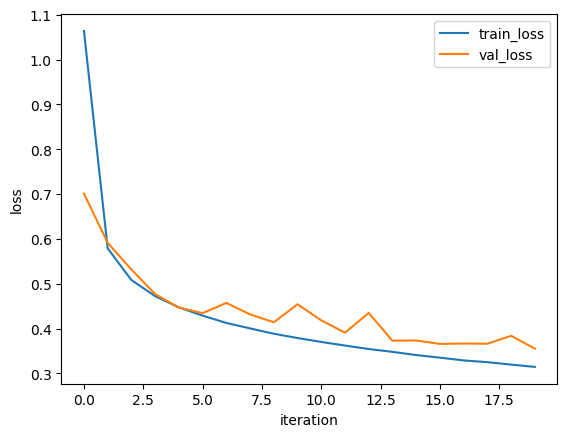

In [24]:
import matplotlib.pyplot as plt
plt.plot(cn_tf.losses)
plt.plot(cn_tf.val_losses)
plt.ylabel('loss')
plt.xlabel('iteration')
plt.legend(['train_loss', 'val_loss'])
plt.show()

In [26]:
cn_tf.score(x_val, y_val_encoded)

np.float64(0.8753333333333333)

In [29]:
# torch input
x_train_t = torch.tensor(x_train).reshape(-1, 1, 28, 28)
x_val_t = torch.tensor(x_val).reshape(-1, 1, 28, 28)
print(x_train_t.shape)

torch.Size([48000, 1, 28, 28])


In [31]:
cn_torch = ConvolutionNetwork_torch(n_kernels=10, units=100, batch_size=128, learning_rate=0.01)
cn_torch.fit(x_train_t, y_train_encoded, x_val=x_val_t, y_val=y_val_encoded, epochs=20)

에포크 0 ......................

C:\Users\USER\AppData\Local\Temp\ipykernel_16428\2550917535.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32)


.................................................................................................................................................................................................................................................................................................................................................................
에포크 1 .......................................................................................................................................................................................................................................................................................................................................................................................
에포크 2 ..................................................................................................................................................................................................................................................................

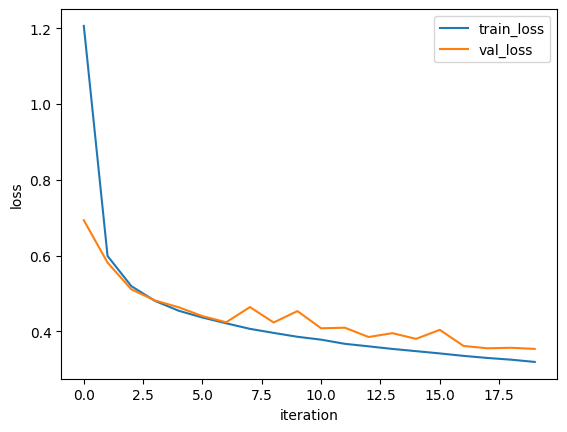

In [32]:
import matplotlib.pyplot as plt
plt.plot(cn_torch.losses)
plt.plot(cn_torch.val_losses)
plt.ylabel('loss')
plt.xlabel('iteration')
plt.legend(['train_loss', 'val_loss'])
plt.show()

In [37]:
cn_torch.score(x_val_t, y_val_encoded)

C:\Users\USER\AppData\Local\Temp\ipykernel_16428\2550917535.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32)


np.float64(0.87875)

In [38]:
x_test_t = torch.tensor(x_test / 255.0).float().reshape(-1, 1, 28, 28)
y_test_encoded = tf.keras.utils.to_categorical(y_test)
cn_torch.score(x_test_t, y_test_encoded)

C:\Users\USER\AppData\Local\Temp\ipykernel_16428\2550917535.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32)


np.float64(0.8654)